Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = tanh(0.5*1.0 + 0.8*0.0) = 0.4621

Final Hidden States: [np.float64(0.46211715726000974)]
Time step 2:
Input x_2 = 2.0
h_2 = tanh(0.5*2.0 + 0.8*0.46211715726000974) = 0.8786

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898)]
Time step 3:
Input x_3 = 3.0
h_3 = tanh(0.5*3.0 + 0.8*0.8786223746838898) = 0.9759

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898), np.float64(0.9758816208890569)]


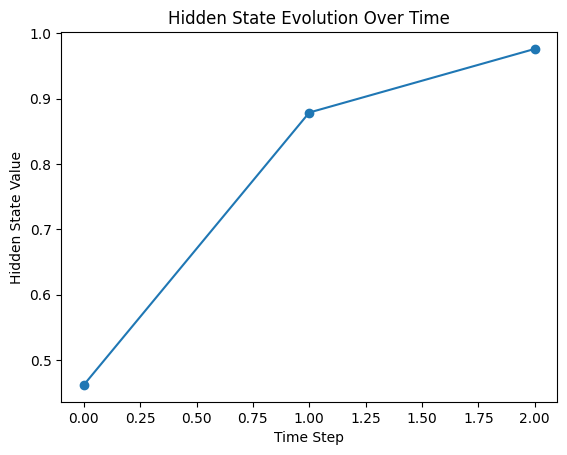

In [2]:
import numpy as np
# Sequence: x1, x2, x3
X = [1.0, 2.0, 3.0]
# Weight matrices (scalar case for simplicity)
Wx = 0.5   # input weight
Wh = 0.8   # hidden weight
b = 0.0    # bias

# Initial hidden state
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)
    
    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev}) = {h_t:.4f}\n")
    
    hidden_states.append(h_t)
    h_prev = h_t
    print("Final Hidden States:", hidden_states)

import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

Step-by-step RNN computation:

Time step 1:
Input x_1 = 3.0
h_1 = tanh(0.5*3.0 + 0.8*0.0) = 0.9051

Final Hidden States: [np.float64(0.9051482536448665)]
Time step 2:
Input x_2 = 4.0
h_2 = tanh(0.5*4.0 + 0.8*0.9051482536448665) = 0.9914

Final Hidden States: [np.float64(0.9051482536448665), np.float64(0.9914291183462953)]
Time step 3:
Input x_3 = 5.0
h_3 = tanh(0.5*5.0 + 0.8*0.9914291183462953) = 0.9972

Final Hidden States: [np.float64(0.9051482536448665), np.float64(0.9914291183462953), np.float64(0.9972454952330853)]


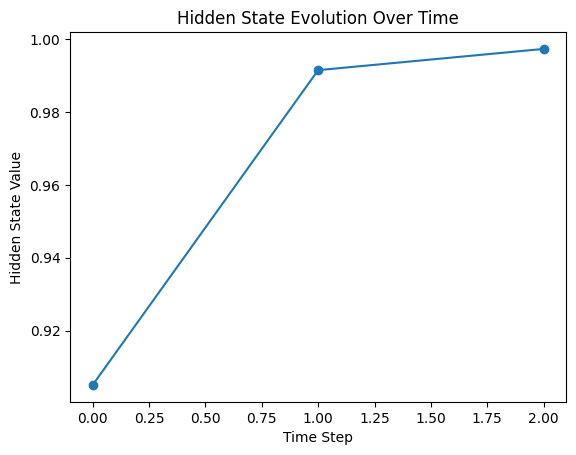

In [3]:
import numpy as np
# Sequence: x1, x2, x3
X = [3.0, 4.0, 5.0]
# Weight matrices (scalar case for simplicity)
Wx = 0.5   # input weight
Wh = 0.8   # hidden weight
b = 0.0    # bias

# Initial hidden state
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)
    
    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev}) = {h_t:.4f}\n")
    
    hidden_states.append(h_t)
    h_prev = h_t
    print("Final Hidden States:", hidden_states)

import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

In [4]:
import numpy as np

# -------------------------
# 1. Input sequence
# -------------------------
X = [1.0, 2.0, 3.0]
target = 0.5   # desired output

# -------------------------
# 2. Initialize parameters
# -------------------------
Wx = 0.5
Wh = 0.8
Wy = 1.0
b = 0.0

# Learning rate
lr = 0.01

# -------------------------
# 3. Activation functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]   # h0 = 0

for t in range(len(X)):
    h_t = tanh(Wx * X[t] + Wh * h[t] + b)
    h.append(h_t)

# Output (many-to-one)
y_pred = Wy * h[-1]

# Loss (Mean Squared Error)
loss = 0.5 * (y_pred - target)**2

print("Forward Pass:")
print("Hidden states:", h[1:])
print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------

# Gradients initialization
dWx = 0
dWh = 0
dWy = 0
db = 0

# Output gradient
dy = (y_pred - target)

# Gradient for Wy
dWy = dy * h[-1]

# Backprop through time
dh_next = dy * Wy   # gradient flowing into last hidden state

for t in reversed(range(len(X))):
    
    # derivative of tanh
    dt = dtanh(Wx * X[t] + Wh * h[t] + b)
    
    # current gradient
    dh = dh_next * dt
    print(f"\nTime step {t}")
    print("dh:", dh)
    # accumulate gradients
    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh
    
    # pass gradient backward in time
    dh_next = dh * Wh
      # PRINT AFTER UPDATING dh_next
    print("dh_next:", dh_next)
print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db:", db)

# -------------------------
# 6. Update weights
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b:", b)



Forward Pass:
Hidden states: [np.float64(0.46211715726000974), np.float64(0.8786223746838898), np.float64(0.9758816208890569)]
Prediction: 0.9758816208890569
Loss: 0.11323165854999806

Time step 2
dh: 0.02267816815333795
dh_next: 0.01814253452267036

Time step 1
dh: 0.0041369101186258935
dh_next: 0.003309528094900715

Time step 0
dh: 0.0026027708674217116
dh_next: 0.0020822166939373694

Gradients:
dWx: 0.07891109556468734
dWh: 0.02183728310022592
dWy: 0.4644041275445246
db: 0.029417849139385555

Updated Parameters:
Wx: 0.4992108890443531
Wh: 0.7997816271689978
Wy: 0.9953559587245547
b: -0.00029417849139385554


In [5]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


vocab_size = 5000
max_len = 200
embed_size=32
hidden_size=32

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
    SimpleRNN(hidden_size),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.6873 - loss: 0.5751
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8215 - loss: 0.4094
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.8743 - loss: 0.3075
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8995 - loss: 0.2502
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.9332 - loss: 0.1776
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9266 - loss: 0.1854
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9696 - loss: 0.0919
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.9623 - loss: 0.1028
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.9831 - loss: 0.0517
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.9915 - loss: 0.0296
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.9882 - loss: 0.0391
Epoch 12/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 